In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import ast

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', None) 
pd.set_option('display.max_columns', None) 

In [12]:
data = pd.read_csv('/Users/oguzhanerbil/Documents/Repolarım/food-health-predictor/data/data.csv')

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41515 entries, 0 to 41514
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   barkod                      41514 non-null  float64
 1   miktar                      35377 non-null  float64
 2   markalar                    40337 non-null  object 
 3   alerjenler                  41515 non-null  object 
 4   eser_miktarlar              41515 non-null  object 
 5   icerik_sayisi               37932 non-null  float64
 6   nutriscore_notu             41458 non-null  object 
 7   nova_grubu                  36695 non-null  float64
 8   yesil_skor_notu             31301 non-null  object 
 9   palmiye_yagi_icermez        35524 non-null  object 
 10  vejetaryen                  33425 non-null  object 
 11  vegan_durumu                38083 non-null  object 
 12  enerji_kcal                 40997 non-null  float64
 13  yag_g                       409

In [14]:
data.describe()

,barkod,miktar,icerik_sayisi,nova_grubu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde
count,4.151400e+04,3.537700e+04,37932.000000,36695.000000,40997.000000,40993.000000,40631.000000,40960.000000,40830.000000,30272.000000,40990.000000,41122.000000,2011.000000,11120.000000
mean,4.367431e+12,1.961890e+08,12.856427,3.122823,288.819036,15.019250,5.572087,29.107966,12.278813,3.479218,7.821958,10.190880,3.592162,14.108718
std,2.499675e+12,3.202824e+10,13.147723,1.146697,365.717943,34.958407,9.892893,30.763857,22.679870,5.268405,10.178297,1755.564181,16.710662,33.123181
min,1.526000e+03,0.000000e+00,1.000000,1.000000,0.000000,-0.880969,-0.126229,0.000000,0.000000,0.000000,0.000000,-0.179539,0.000000,-0.031250
25%,3.256221e+12,7.500000e+01,4.000000,3.000000,85.000000,1.000000,0.200000,4.300000,0.700000,0.500000,1.800000,0.030000,0.000000,0.000000
50%,3.770033e+12,2.000000e+02,10.000000,4.000000,267.000000,6.800000,1.500000,15.000000,3.700000,2.100000,6.200000,0.300000,0.000000,0.000000
75%,5.740900e+12,4.000000e+02,18.000000,4.000000,447.000000,23.000000,7.500000,56.000000,14.000000,4.800000,10.714286,0.980000,0.000000,5.000000
max,9.327007e+13,5.940568e+12,405.000000,4.000000,44600.000000,5856.650000,450.000000,1900.000000,1500.000000,375.000000,800.000000,355942.500000,100.000000,449.400000


In [15]:
data.sample(5)

,barkod,miktar,markalar,alerjenler,eser_miktarlar,icerik_sayisi,nutriscore_notu,nova_grubu,yesil_skor_notu,palmiye_yagi_icermez,vejetaryen,vegan_durumu,enerji_kcal,yag_g,doymus_yag_g,karbonhidrat_g,seker_g,lif_g,protein_g,tuz_g,alkol_yuzde,meyve_sebze_baklagil_yuzde,birim,kategori_listesi,etiketler_listesi
8623,3.580282e+12,680.0,poitou charente,[],[],2.0,A,NaN,B,False,True,yes,149.0,2.30,0.4,19.00,0.50,8.1,9.3,0.00000,NaN,NaN,g,"['Plant-based foods and beverages', 'Plant-bas...",['Made in France']
19752,4.063367e+12,1.0,bioland kaufland,[],[],4.0,C,NaN,C,False,True,yes,68.0,3.90,2.4,4.80,4.80,NaN,3.4,0.09000,NaN,NaN,l,"['Beverages and beverages preparations', 'Beve...","['Organic', 'EU Organic', 'EG-Öko-Verordnung',..."
27178,5.600500e+12,21.5,prozis,"['Eggs', 'Gluten', 'Milk', 'Soybeans']",[],33.0,D,4.0,NaN,False,True,no,488.0,35.00,21.0,51.00,6.50,2.3,6.6,0.22000,39.0,NaN,g,"['Snacks', 'Sweet snacks', 'Cocoa and its prod...",['Sans sucre ajouté']
17512,5.941905e+12,NaN,artesana,[],[],NaN,C,NaN,D,NaN,NaN,NaN,69.0,3.68,2.4,5.42,5.32,0.0,3.5,0.00022,NaN,NaN,NaN,"['Dairies', 'Milks (liquid and powder)', 'Milk...",[]
41493,3.046920e+12,NaN,lindt,[],"['Milk', 'Nuts', 'Soybeans']",7.0,E,1.0,A,False,True,yes,603.0,55.00,36.0,19.00,14.00,NaN,8.9,0.08000,NaN,0.0,NaN,"['Snacks', 'Sweet snacks', 'Cocoa and its prod...",[]


In [16]:
data.isnull().mean() * 100

barkod                         0.002409
miktar                        14.785017
markalar                       2.837529
alerjenler                     0.000000
eser_miktarlar                 0.000000
icerik_sayisi                  8.630615
nutriscore_notu                0.137300
nova_grubu                    11.610261
yesil_skor_notu               24.603155
palmiye_yagi_icermez          14.430929
vejetaryen                    19.486932
vegan_durumu                   8.266891
enerji_kcal                    1.247742
yag_g                          1.257377
doymus_yag_g                   2.129351
karbonhidrat_g                 1.336866
seker_g                        1.650006
lif_g                         27.081778
protein_g                      1.264603
tuz_g                          0.946646
alkol_yuzde                   95.155968
meyve_sebze_baklagil_yuzde    73.214501
birim                         16.825244
kategori_listesi               0.000000
etiketler_listesi              0.000000


In [17]:
for column in data.columns:
    unique_values = data[column].astype(str).unique()
    unique_values_str = sorted(list(unique_values))
    n = 10
    displayed_values = unique_values_str[:n]
    print(f"{column} ({len(unique_values_str)}): {displayed_values}{' ...' if len(unique_values_str) > n else ''}")

barkod (41433): ['10001219.0', '10001295.0', '10001400.0', '10001404.0', '10001691.0', '10001707.0', '10001875.0', '10013108.0', '10015599.0', '10023242.0'] ...
miktar (967): ['0.0', '0.045', '0.046', '0.055', '0.06', '0.07', '0.08', '0.081', '0.085', '0.09'] ...
markalar (8363): ['"tradition culinaire"', "'z bregov", '(sans marque)', '07x netto 03.25', '1 2 3 fruits', '1 attimo in forma', '1 l', '1 x auer 01.25', '100 plus', '1001 delights'] ...
alerjenler (1351): ["['Acesulfame-potassium']", "['Apple', 'Banana', 'Celery', 'Peach']", "['Apple', 'Banana', 'Gluten', 'Kiwi', 'Milk', 'Orange', 'Peach']", "['Apple', 'Banana', 'Gluten', 'Nuts']", "['Apple', 'Banana', 'Gluten', 'Sulphur dioxide and sulphites']", "['Apple', 'Banana', 'Kiwi', 'Milk', 'Orange', 'Peach']", "['Apple', 'Banana', 'Kiwi', 'Orange', 'Peach']", "['Apple', 'Banana', 'Milk']", "['Apple', 'Banana', 'Orange', 'Peach']", "['Apple', 'Celery', 'Gluten', 'Mustard', 'Soybeans']"] ...
eser_miktarlar (1863): ["['0756yc051253']",

In [18]:
df = data.copy()

def convert_to_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            val = ast.literal_eval(s)
            return val if isinstance(val, list) else [val]
        except:
            return [p.strip() for p in s.split(',') if p.strip()]
    return []

for col in ['eser_miktarlar','kategori_listesi','alerjenler','etiketler_listesi',"markalar"]:
    s = df[col].apply(convert_to_list).explode().dropna().astype(str)
    s = s[s != '']
    counts = s.value_counts()
    print(f"--- {col} - Top 50 ---")
    print(counts.head(50))
    print(f"\nToplam Benzersiz {col}: {len(counts)}\n")


--- eser_miktarlar - Top 50 ---
eser_miktarlar
Nuts                                                     7058
Soybeans                                                 5033
Milk                                                     4103
Gluten                                                   3269
Eggs                                                     2945
Sesame seeds                                             2900
Mustard                                                  2390
Peanuts                                                  1930
Celery                                                   1443
Fish                                                      743
Crustaceans                                               633
Molluscs                                                  557
Lupin                                                     504
Sulphur dioxide and sulphites                             331
Crustaceans-and-shellfish                                  22
Cereals-with-gluten    

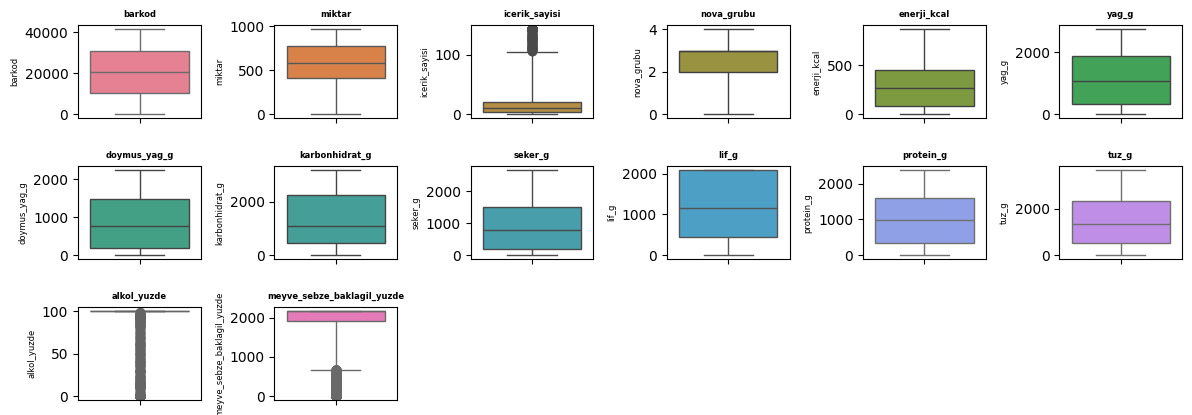

In [19]:
from sklearn.calibration import LabelEncoder
import seaborn as sns

veri = data.copy()

selected_columns = veri.select_dtypes(include=['number']).columns.tolist()

label_encoder = LabelEncoder()

for column in selected_columns:
    veri[column] = label_encoder.fit_transform(veri[column])

# Plot sayısını belirleyip subplotları ayarlayalım
fig, axes = plt.subplots(nrows=int(np.ceil(len(selected_columns)/3)), ncols=6, figsize=(12, 1 * int(np.ceil(len(selected_columns)/2))))

# Renk paleti seçimi
palette = sns.color_palette("husl", len(selected_columns))

# Boxplotları çizelim
axes = axes.flatten()
for i, col in enumerate(selected_columns):
    sns.boxplot(y=col, data=veri, ax=axes[i], color=palette[i], whis=5)
    axes[i].set_title(f'{col}', fontsize=6, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(col, fontsize=6)

# Kullanılmayan subplotları kaldıralım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Grafik düzenini iyileştirelim
plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=2.0)
plt.show()

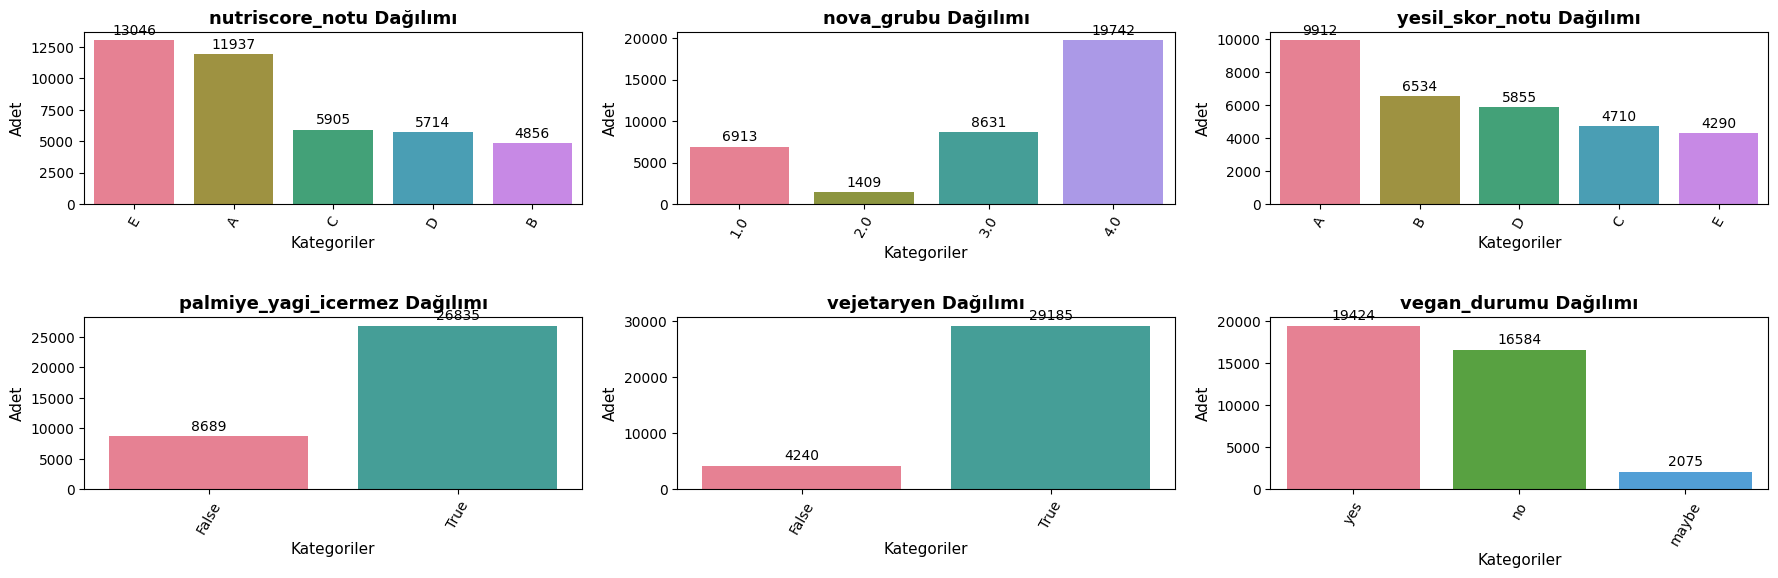

In [20]:
unique_counts = data.nunique()

categorical_columns = unique_counts[unique_counts <= 20].index.tolist()

n_cols = 3
n_rows = int(np.ceil(len(categorical_columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*6, n_rows*3))
axes = axes.flatten()

for i, column in enumerate(categorical_columns):
    val_counts = data[column].value_counts()
    sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[i], palette='husl')
    axes[i].set_title(f'{column} Dağılımı', fontsize=13, fontweight='bold')
    axes[i].set_xlabel("Kategoriler", fontsize=11)
    axes[i].set_ylabel("Adet", fontsize=11)
    axes[i].tick_params(axis='x', rotation=60)

    # Her sütunun üzerine değerleri ekleyelim
    for p in axes[i].patches:
        axes[i].annotate(format(p.get_height(), '.0f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', fontsize=10, color='black', xytext=(0, 7),
                         textcoords='offset points')

# Kullanılmayan subplotları kaldıralım
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.5, w_pad=1.5, h_pad=2.5)
plt.show()
